# 02 - Train Models

We train two models on the synthetic chart dataset from notebook 01:
1. **PatternCNN** — custom CNN built from scratch (3 conv blocks + global average pooling)
2. **ResNet-18** — ImageNet pretrained, fine-tuned on our chart images

Training both lets us see if transfer learning actually helps on synthetic chart data,
or if a small custom model is good enough.

In [1]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Data lives in fast local /content/ storage
# Only checkpoints go to Drive so they persist if session disconnects
SYNTHETIC_DIR = Path('/content/data/synthetic')
RESULTS_DIR   = Path('/content/results')

try:
    from google.colab import drive
    drive.mount('/drive')
    CKPT_DIR = Path('/drive/MyDrive/ECE176/checkpoints')
except ImportError:
    CKPT_DIR = Path('.').resolve() / 'checkpoints'

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR / 'figures', exist_ok=True)

BATCH_SIZE = 32
LR         = 1e-3
N_EPOCHS   = 40
PATIENCE   = 10
DROPOUT_P  = 0.5
IMG_SIZE   = 224
DATA_SEED  = 42

CLASS_NAMES = [
    'head_and_shoulders',
    'double_top',
    'descending_triangle',
    'inv_head_and_shoulders',
    'double_bottom',
    'ascending_triangle',
    'no_pattern',
]
N_CLASSES = len(CLASS_NAMES)

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device       : {device}')
print(f'Checkpoints  : {CKPT_DIR}')


Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Device       : cuda
Checkpoints  : /drive/MyDrive/ECE176/checkpoints


In [2]:
assert SYNTHETIC_DIR.exists(), 'Run notebook 01 first in this same Colab session!'

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(SYNTHETIC_DIR / 'train', transform=train_tfm)
val_ds   = datasets.ImageFolder(SYNTHETIC_DIR / 'val',   transform=val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds)} images')
print(f'Val   : {len(val_ds)} images')


Train : 8925 images
Val   : 1575 images


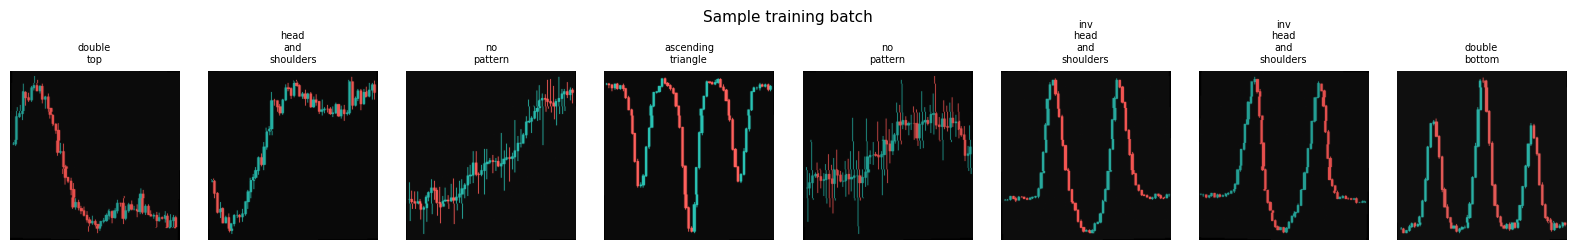

In [3]:
imgs, labels = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
imgs_show = (imgs[:8] * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for ax, img, lbl in zip(axes, imgs_show, labels[:8]):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASS_NAMES[lbl].replace('_', '\n'), fontsize=7)
    ax.axis('off')
plt.suptitle('Sample training batch', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'train_batch_sample.png', dpi=100, bbox_inches='tight')
plt.show()


## Model Definitions

### PatternCNN
Three conv blocks (3→32→64→128), each with BatchNorm + ReLU + MaxPool.
Global Average Pooling then two FC layers with dropout.

### ResNet-18
Pretrained on ImageNet. We replace the final FC layer with a 7-class head
and fine-tune the whole network.

In [4]:
class PatternCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES, dropout=DROPOUT_P):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3,   32),   # 224 → 112
            conv_block(32,  64),   # 112 → 56
            conv_block(64, 128),   # 56  → 28
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


def build_resnet18(n_classes=N_CLASSES):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(512, n_classes)
    return model


cnn_model    = PatternCNN().to(device)
resnet_model = build_resnet18().to(device)

print(f'PatternCNN params : {sum(p.numel() for p in cnn_model.parameters()):,}')
print(f'ResNet-18  params : {sum(p.numel() for p in resnet_model.parameters()):,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


PatternCNN params : 128,519
ResNet-18  params : 11,180,103


## Training

Same setup for both models:
- **Loss:** CrossEntropyLoss
- **Optimizer:** Adam lr=1e-3, StepLR halves it every 10 epochs
- **Early stopping:** stops if val acc doesn't improve for 10 epochs
- **Gradient clipping:** max norm 1.0

In [5]:
def train_model(model, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc    = 0.0
    no_improve      = 0
    ckpt_path       = CKPT_DIR / f'{model_name}_best.pt'

    for epoch in range(1, N_EPOCHS + 1):
        t0 = time.time()

        # train
        model.train()
        t_loss, t_correct = 0.0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss    += loss.item() * imgs.size(0)
            t_correct += (out.argmax(1) == labels).sum().item()

        # val
        model.eval()
        v_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()

        scheduler.step()

        tl = t_loss / len(train_ds);  ta = t_correct / len(train_ds)
        vl = v_loss / len(val_ds);    va = v_correct / len(val_ds)

        history['train_loss'].append(tl);  history['train_acc'].append(ta)
        history['val_loss'].append(vl);    history['val_acc'].append(va)

        print(f'Epoch {epoch:02d}  loss={tl:.3f}/{vl:.3f}  acc={ta:.3f}/{va:.3f}  ({time.time()-t0:.1f}s)')

        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), ckpt_path)
            print(f'  -> saved (val_acc={best_val_acc:.4f})')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break

    print(f'Done. Best val acc: {best_val_acc:.4f}  |  checkpoint: {ckpt_path}')
    return history


In [6]:
print('Training PatternCNN...')
cnn_history = train_model(cnn_model, 'cnn')


Training PatternCNN...
Epoch 01  loss=0.912/1.735  acc=0.611/0.429  (22.6s)
  -> saved (val_acc=0.4286)
Epoch 02  loss=0.161/0.022  acc=0.968/0.998  (21.0s)
  -> saved (val_acc=0.9981)
Epoch 03  loss=0.037/0.012  acc=0.994/1.000  (20.5s)
  -> saved (val_acc=1.0000)
Epoch 04  loss=0.020/0.012  acc=0.995/0.999  (20.6s)
Epoch 05  loss=0.008/0.000  acc=0.999/1.000  (20.6s)
Epoch 06  loss=0.008/2.918  acc=0.999/0.568  (20.6s)
Epoch 07  loss=0.011/8.265  acc=0.998/0.286  (20.5s)
Epoch 08  loss=0.005/0.001  acc=0.999/1.000  (20.8s)
Epoch 09  loss=0.006/0.000  acc=0.999/1.000  (20.5s)
Epoch 10  loss=0.004/0.000  acc=0.999/1.000  (20.6s)
Epoch 11  loss=0.001/0.142  acc=1.000/0.931  (20.7s)
Epoch 12  loss=0.001/0.000  acc=1.000/1.000  (20.7s)
Epoch 13  loss=0.000/0.000  acc=1.000/1.000  (20.6s)
Early stopping at epoch 13
Done. Best val acc: 1.0000  |  checkpoint: /drive/MyDrive/ECE176/checkpoints/cnn_best.pt


In [7]:
print('Training ResNet-18...')
resnet_model = build_resnet18().to(device)
resnet_history = train_model(resnet_model, 'resnet')


Training ResNet-18...
Epoch 01  loss=0.024/0.053  acc=0.993/0.986  (32.2s)
  -> saved (val_acc=0.9860)
Epoch 02  loss=0.003/0.000  acc=0.999/1.000  (32.3s)
  -> saved (val_acc=1.0000)
Epoch 03  loss=0.000/0.000  acc=1.000/1.000  (32.2s)
Epoch 04  loss=0.000/0.000  acc=1.000/1.000  (31.9s)
Epoch 05  loss=0.000/0.000  acc=1.000/1.000  (32.0s)
Epoch 06  loss=0.000/0.000  acc=1.000/1.000  (32.1s)
Epoch 07  loss=0.000/0.000  acc=1.000/1.000  (32.1s)
Epoch 08  loss=0.000/0.000  acc=1.000/1.000  (32.1s)
Epoch 09  loss=0.000/0.000  acc=1.000/1.000  (32.1s)
Epoch 10  loss=0.000/0.000  acc=1.000/1.000  (32.1s)
Epoch 11  loss=0.004/0.000  acc=0.999/1.000  (32.2s)
Epoch 12  loss=0.002/0.000  acc=0.999/1.000  (32.1s)
Early stopping at epoch 12
Done. Best val acc: 1.0000  |  checkpoint: /drive/MyDrive/ECE176/checkpoints/resnet_best.pt


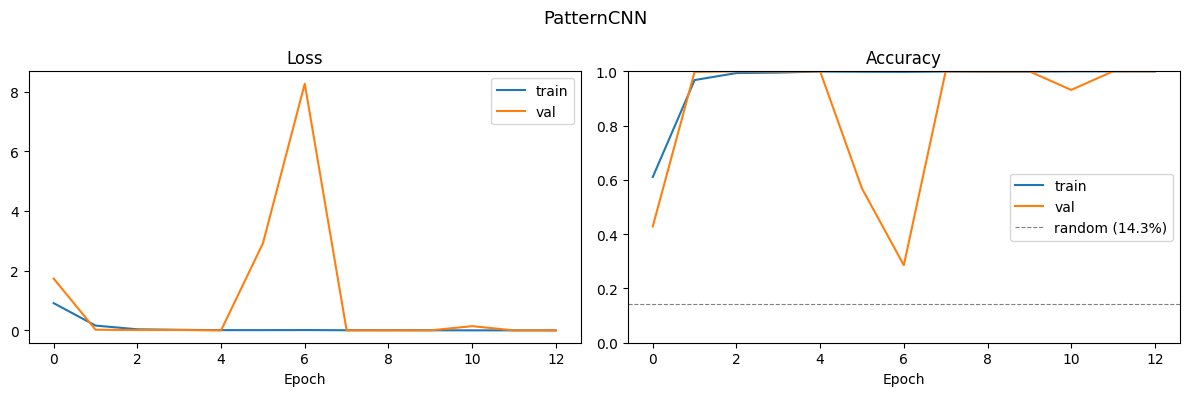

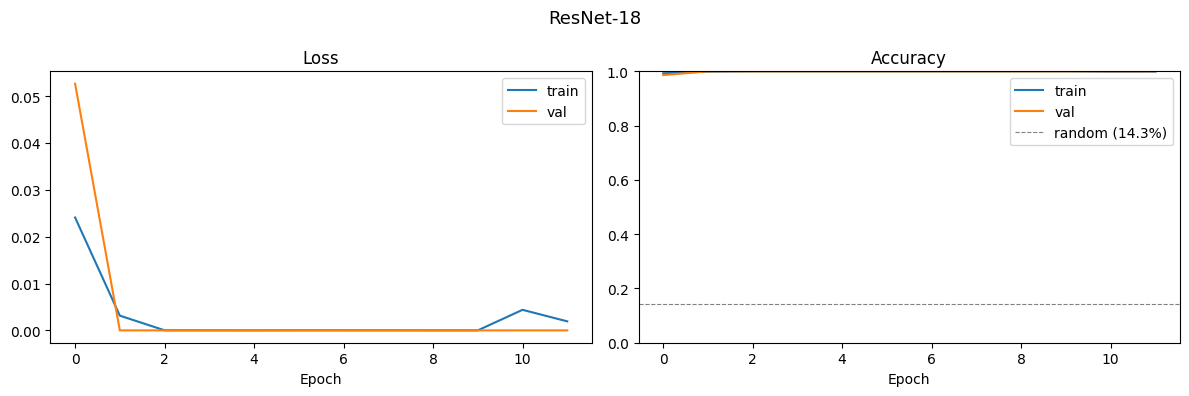

In [8]:
def plot_history(history, title, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'],   label='val')
    ax1.set_title('Loss');  ax1.set_xlabel('Epoch');  ax1.legend()

    ax2.plot(history['train_acc'], label='train')
    ax2.plot(history['val_acc'],   label='val')
    ax2.axhline(1/7, color='gray', linestyle='--', linewidth=0.8, label='random (14.3%)')
    ax2.set_title('Accuracy');  ax2.set_xlabel('Epoch');  ax2.set_ylim(0, 1);  ax2.legend()

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures' / save_name, dpi=120, bbox_inches='tight')
    plt.show()

plot_history(cnn_history,    'PatternCNN',  'cnn_curves.png')
plot_history(resnet_history, 'ResNet-18',   'resnet_curves.png')


PatternCNN  ->  val accuracy: 100.0%


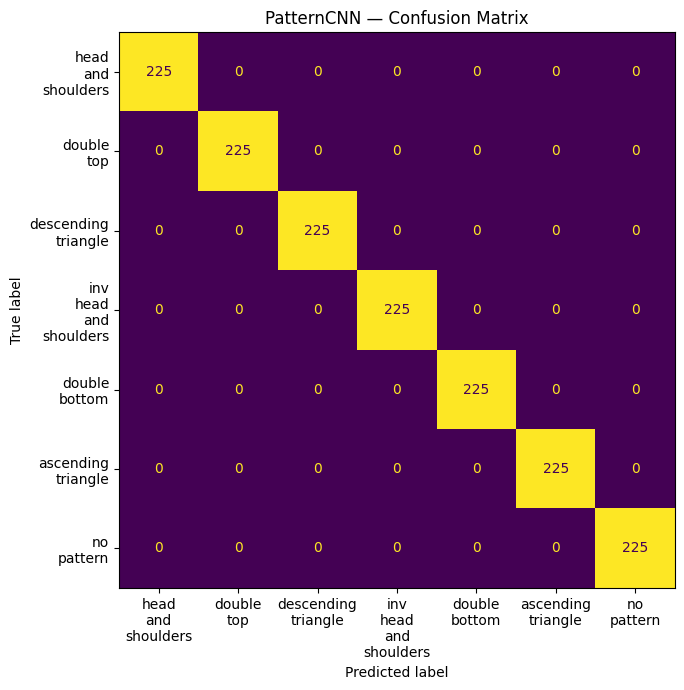

ResNet-18  ->  val accuracy: 100.0%


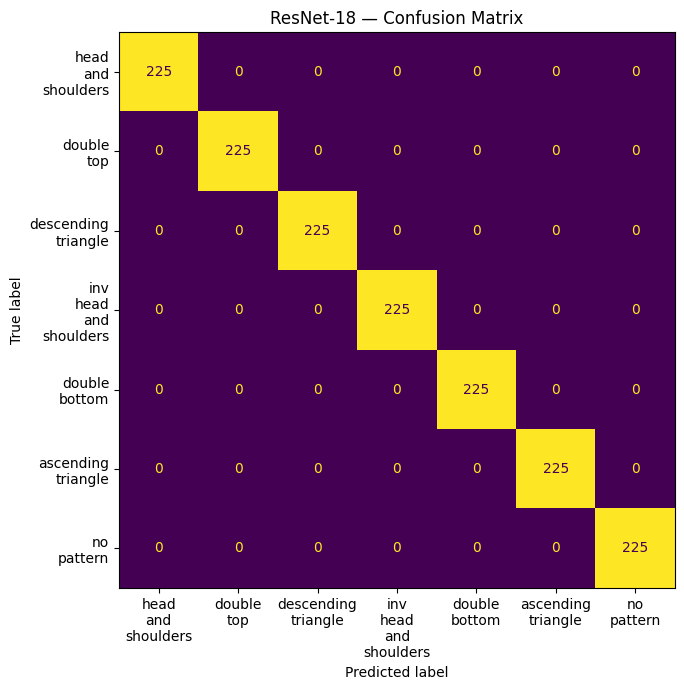


PatternCNN : 100.0%
ResNet-18  : 100.0%
Random     : 14.3%


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def eval_model(model, ckpt_name, title):
    model.load_state_dict(torch.load(CKPT_DIR / f'{ckpt_name}_best.pt', map_location=device))
    model.eval()

    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            preds = model(imgs.to(device)).argmax(1).cpu()
            preds_all.extend(preds.numpy())
            labels_all.extend(labels.numpy())

    acc = (np.array(preds_all) == np.array(labels_all)).mean()
    print(f'{title}  ->  val accuracy: {acc*100:.1f}%')

    cm = confusion_matrix(labels_all, preds_all)
    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay(cm, display_labels=[c.replace('_','\n') for c in CLASS_NAMES]).plot(ax=ax, colorbar=False)
    ax.set_title(f'{title} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures' / f'{ckpt_name}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()
    return acc

cnn_acc    = eval_model(cnn_model,    'cnn',    'PatternCNN')
resnet_acc = eval_model(resnet_model, 'resnet', 'ResNet-18')

print(f'\nPatternCNN : {cnn_acc*100:.1f}%')
print(f'ResNet-18  : {resnet_acc*100:.1f}%')
print(f'Random     : {100/7:.1f}%')
